Loaded JSON Lines format

Dataset Loaded Successfully

Columns:
Index(['content', 'annotation', 'extras'], dtype='object')

Dataset Shape: (220, 7)

Training Shape: (176, 3003)
Testing Shape: (44, 3003)

Model Training Completed

First 10 Predictions:
[851.62 155.2  822.5  270.7  298.12 372.82  70.04 124.92 598.06 503.1 ]

MSE: 0.0
RMSE: 0.0001
R2 Score: 1.0
Accuracy: 100.0 %

Predicted Candidate Score:
46.42


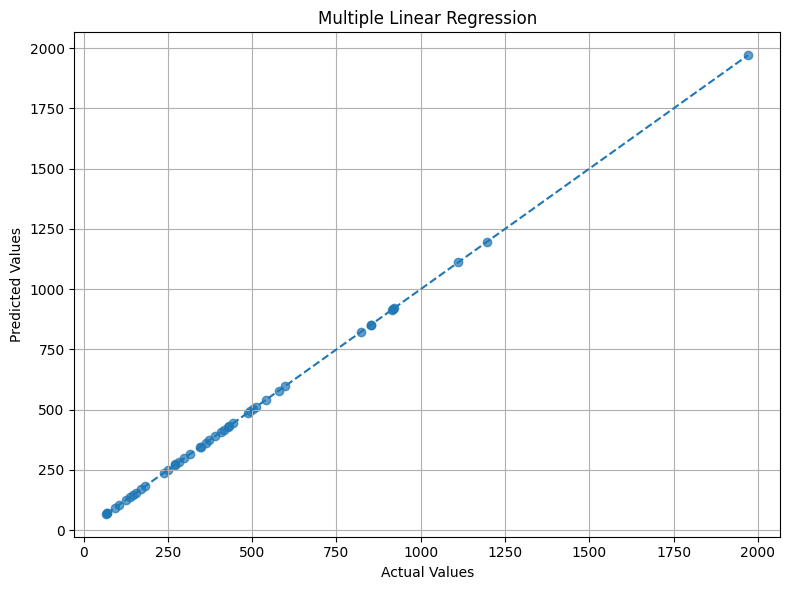

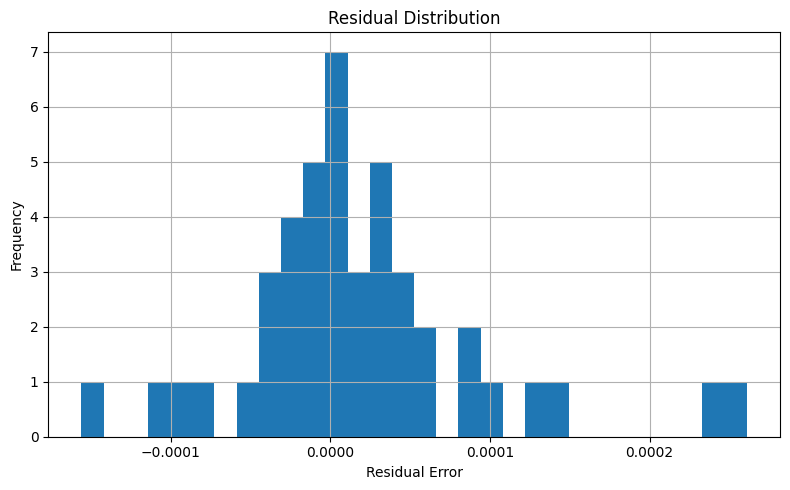


Top Features:
                  Feature  Coefficient
3002     annotation_count     5.000000
3001           word_count     0.499998
3000        resume_length     0.020000
192                   atm     0.000144
441                 cisco     0.000102
2449            smartform     0.000099
2626                 team     0.000096
748   developed smartform     0.000090
325                branch     0.000089
291                    bi     0.000073
1946                 port     0.000073
1923                 plan     0.000073
586             countries     0.000071
299               billion     0.000071
2528                steel     0.000070
908                   esb     0.000069
1453                 lead     0.000068
1700                 mule     0.000066
2368               server     0.000066
747             developed     0.000064

Model Saved Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score
)

json_file = "resume_dataset.json"

try:
    data = pd.read_json(json_file, lines=True)
    print("Loaded JSON Lines format")
except:
    data = pd.read_json(json_file)
    print("Loaded Standard JSON format")

print("\nDataset Loaded Successfully")

print("\nColumns:")
print(data.columns)

text_col = "content"

data["resume_length"] = data[text_col].astype(str).apply(len)

data["word_count"] = data[text_col].astype(str).apply(
    lambda x: len(x.split())
)

data["annotation_count"] = data["annotation"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

data["Generated_Score"] = (
    data["resume_length"] * 0.02
    + data["word_count"] * 0.5
    + data["annotation_count"] * 5
)

target_col = "Generated_Score"

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

data[text_col] = data[text_col].apply(clean_text)

data = data.dropna(subset=[text_col])

data = data[data[text_col].str.strip() != ""]

print("\nDataset Shape:", data.shape)

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2)
)

text_features = vectorizer.fit_transform(data[text_col])

text_df = pd.DataFrame(
    text_features.toarray(),
    columns=vectorizer.get_feature_names_out()
)

extra_features = data[
    [
        "resume_length",
        "word_count",
        "annotation_count"
    ]
].reset_index(drop=True)

X = pd.concat(
    [text_df, extra_features],
    axis=1
)

y = data[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(np.round(y_pred[:10], 2))

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMSE:", round(mse, 4))

print("RMSE:", round(rmse, 4))

print("R2 Score:", round(r2, 4))

y_test_int = np.round(y_test).astype(int)

y_pred_int = np.round(y_pred).astype(int)

accuracy = accuracy_score(
    y_test_int,
    y_pred_int
)

print("Accuracy:", round(accuracy * 100, 2), "%")

new_resume = """
Python Machine Learning Deep Learning
SQL NLP TensorFlow Data Science
"""

new_resume_clean = clean_text(new_resume)

new_text = vectorizer.transform(
    [new_resume_clean]
)

new_text_df = pd.DataFrame(
    new_text.toarray(),
    columns=vectorizer.get_feature_names_out()
)

new_extra = pd.DataFrame({
    "resume_length": [len(new_resume)],
    "word_count": [len(new_resume.split())],
    "annotation_count": [8]
})

new_input = pd.concat(
    [new_text_df, new_extra],
    axis=1
)

prediction = model.predict(new_input)

print("\nPredicted Candidate Score:")
print(round(float(prediction[0]), 2))

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())

max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Multiple Linear Regression")

plt.grid(True)

plt.tight_layout()

plt.savefig("multiple_linear_regression.png")

plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(True)

plt.tight_layout()

plt.savefig("residual_distribution.png")

plt.show()

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop Features:")

print(feature_importance.head(20))

joblib.dump(
    model,
    "multiple_linear_regression_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print("\nModel Saved Successfully")